# Creating and Training the CNN

In [2]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.layers import StringLookup

%matplotlib inline

IMG_SIZE = 150
BATCH_SIZE = 32
EPOCHS = 30
MIN_SAMPLES_PER_CLASS = 5

### Loading Annotations and Filtering Classes

In [3]:
with open('micronet_annotations.json', 'r') as f:
    annotations = json.load(f)

# we count the frequency of every class
class_counts = Counter(v['species_guess'] for v in annotations.values())

# get rid of classes that have less than the min samples
valid_classes = sorted([label for label, count in class_counts.items() if count >= MIN_SAMPLES_PER_CLASS])

print(f"Total Classes: {len(class_counts)}")
print(f"Valid Classes (>= {MIN_SAMPLES_PER_CLASS} images): {len(valid_classes)}")

# initialize encoder with valid classes
label_encoder = StringLookup(vocabulary=valid_classes, mask_token=None, num_oov_indices=0)
num_classes = len(valid_classes)

Total Classes: 2611
Valid Classes (>= 5 images): 409


I0000 00:00:1776455664.717089  176671 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79076 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:47:00.0, compute capability: 8.0


### Making Dataframes

In [4]:
print(f"Current Jupyter Folder: {os.getcwd()}")
print("--- Creating DataFrames (Diagnostic Mode) ---")

def create_split_df(json_path):
    with open(json_path, 'r') as f:
        uuids = json.load(f)
        
    data = []
    missing_files = 0
    missing_annotation = 0
    filtered_out = 0
    
    for uid in uuids:
        img_path = f"micronet_images/{uid}.jpg"
        
        # does python see image?
        if not os.path.exists(img_path):
            missing_files += 1
            continue
            
        # id in master JSON?
        if uid not in annotations:
            missing_annotation += 1
            continue
            
        # species survive filter?
        label = annotations[uid]['species_guess']
        if label not in valid_classes:
            filtered_out += 1
            continue
            
        data.append({
            'path': img_path,
            'label': label
        })
        
    print(f"Stats for {json_path}:")
    print(f"  - Total IDs checked: {len(uuids)}")
    print(f"  - Skipped (Missing File): {missing_files}")
    print(f"  - Skipped (No Annotation): {missing_annotation}")
    print(f"  - Skipped (Rare Species): {filtered_out}")
    print(f"  - Successfully Added: {len(data)}")
    print("-" * 40)
    
    if len(data) == 0:
        return pd.DataFrame(columns=['path', 'label'])
        
    return pd.DataFrame(data)

train_df = create_split_df('train.json')
val_df = create_split_df('val.json')
test_df = create_split_df('test.json')

Current Jupyter Folder: /sfs/gpfs/tardis/home/bgc9yp/MicroNetCNN
--- Creating DataFrames (Diagnostic Mode) ---
Stats for train.json:
  - Total IDs checked: 8047
  - Skipped (Missing File): 17
  - Skipped (No Annotation): 0
  - Skipped (Rare Species): 2588
  - Successfully Added: 5442
----------------------------------------
Stats for val.json:
  - Total IDs checked: 1006
  - Skipped (Missing File): 3
  - Skipped (No Annotation): 0
  - Skipped (Rare Species): 321
  - Successfully Added: 682
----------------------------------------
Stats for test.json:
  - Total IDs checked: 1006
  - Skipped (Missing File): 2
  - Skipped (No Annotation): 0
  - Skipped (Rare Species): 320
  - Successfully Added: 684
----------------------------------------


### Building Pipeline

In [5]:
def parse_function(filename, label):
    image_string = tf.io.read_file(filename)
    image = tf.image.decode_image(image_string, channels=3, expand_animations=False)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    # Replace manual float conversion with this:
    image = tf.keras.applications.resnet50.preprocess_input(image) 
    label_idx = label_encoder(label)
    return image, label_idx

def create_dataset(df, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((df['path'].values, df['label'].values))
    if shuffle:
        dataset = dataset.shuffle(len(df))
    dataset = dataset.map(parse_function, num_parallel_calls=tf.data.AUTOTUNE)
    return dataset.cache().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = create_dataset(train_df, shuffle=True)
val_ds = create_dataset(val_df)
test_ds = create_dataset(test_df)

### Checking if the images look right

2026-04-17 15:54:36.106091: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-04-17 15:54:36.291182: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


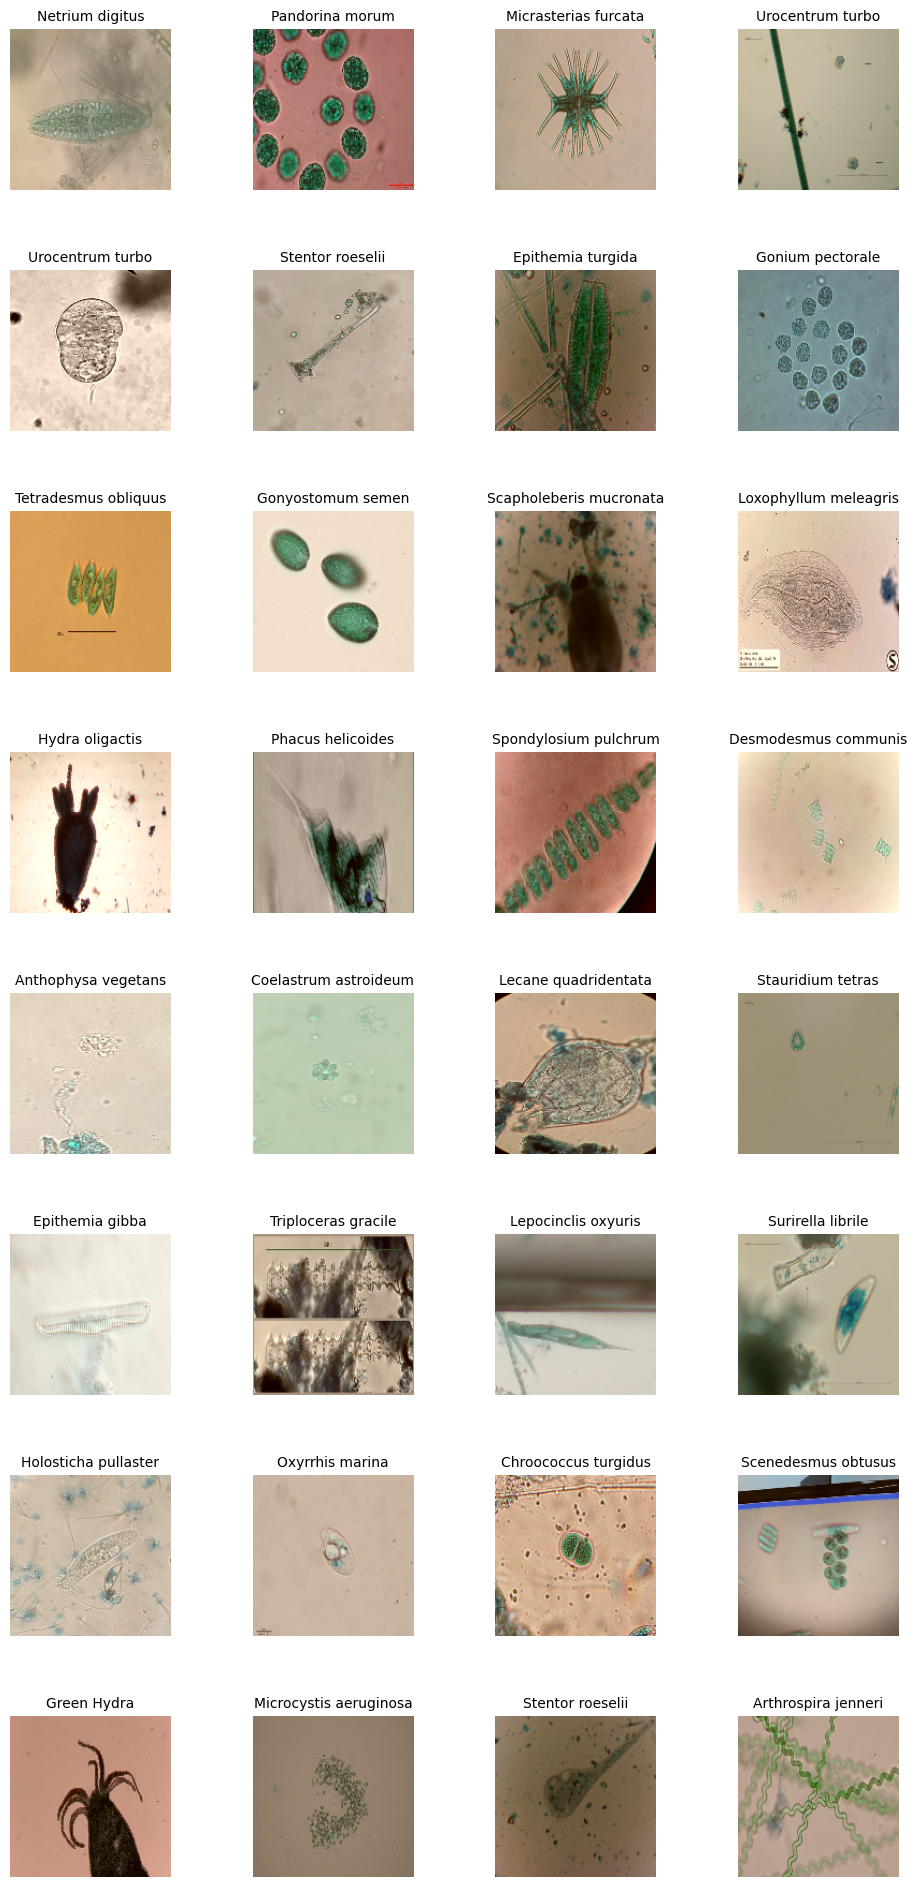

In [7]:
n_rows = 8
n_cols = 4
plt.figure(figsize=(n_cols * 3, n_rows * 3))

for images, labels in train_ds.take(1):
    for i in range(n_rows * n_cols):
        plt.subplot(n_rows, n_cols, i + 1)

        img = images[i].numpy()
        
        # Undo the ResNet50 mean subtraction for visualization only
        # This converts it back to roughly [0, 255]
        img_visual = img + [123.68, 116.779, 103.939] 
        img_visual = np.clip(img_visual, 0, 255).astype('uint8')
        
        plt.imshow(img_visual)
        
        plt.axis('off')
        label_idx = int(labels[i])
        plt.title(valid_classes[label_idx], fontsize=10)

plt.subplots_adjust(wspace=.2, hspace=.5)
plt.show()

### Making CNN

In [8]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1),
])

base_model = tf.keras.applications.ResNet50(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    data_augmentation,
    
    base_model,
    layers.GlobalAveragePooling2D(),
    
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5), 
    
    layers.Dense(num_classes, activation='softmax') 
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 5, 5, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 409)            │       105,113 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,217,369 (92.38 MB)

 Trainable params: 629,657 (2.40 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

### Train Model

In [9]:
checkpoint_cb = callbacks.ModelCheckpoint('resnet_best_model.keras', save_best_only=True, monitor='val_accuracy')

early_stopping_cb = callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy')

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=1e-6
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint_cb, early_stopping_cb, reduce_lr],
)

Epoch 1/30


2026-04-17 15:54:53.540748: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


171/171 ━━━━━━━━━━━━━━━━━━━━ 43s 194ms/step - accuracy: 0.0546 - loss: 5.6535 - val_accuracy: 0.0982 - val_loss: 5.2243 - learning_rate: 5.0000e-04
Epoch 2/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.1095 - loss: 4.9760 - val_accuracy: 0.1217 - val_loss: 4.9358 - learning_rate: 5.0000e-04
Epoch 3/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.1384 - loss: 4.6116 - val_accuracy: 0.1437 - val_loss: 4.7113 - learning_rate: 5.0000e-04
Epoch 4/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.1654 - loss: 4.3133 - val_accuracy: 0.1540 - val_loss: 4.5241 - learning_rate: 5.0000e-04
Epoch 5/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.1865 - loss: 4.0567 - val_accuracy: 0.1730 - val_loss: 4.4425 - learning_rate: 5.0000e-04
Epoch 6/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.2121 - loss: 3.8367 - val_accuracy: 0.1760 - val_loss: 4.3789 - learning_rate: 5.0000e-04
Epoch 7/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.

### Plotting Training on Graph

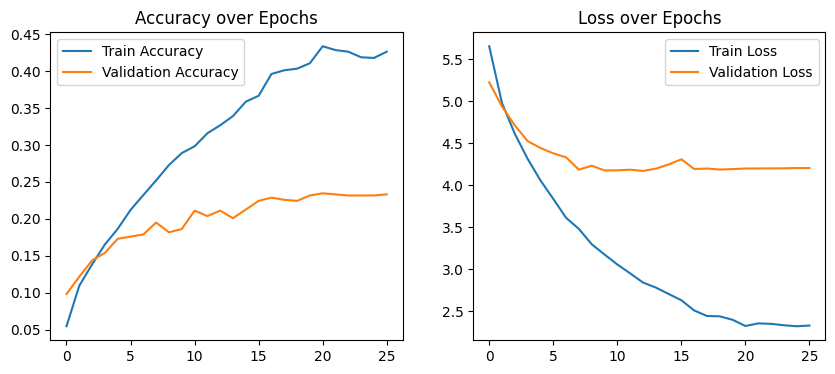

In [10]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.show()

In [11]:
# Unfreeze the base model
base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5), 
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train for another 10-20 epochs
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[checkpoint_cb, early_stopping_cb]
)

Epoch 1/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 41s 93ms/step - accuracy: 0.2183 - loss: 3.8628 - val_accuracy: 0.2126 - val_loss: 4.4331
Epoch 2/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 13s 77ms/step - accuracy: 0.2958 - loss: 3.1608 - val_accuracy: 0.2097 - val_loss: 4.5612
Epoch 3/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 13s 77ms/step - accuracy: 0.3361 - loss: 2.8863 - val_accuracy: 0.2111 - val_loss: 4.5317
Epoch 4/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 14s 80ms/step - accuracy: 0.3697 - loss: 2.6976 - val_accuracy: 0.2243 - val_loss: 4.4989
Epoch 5/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 14s 80ms/step - accuracy: 0.3842 - loss: 2.5708 - val_accuracy: 0.2287 - val_loss: 4.4470


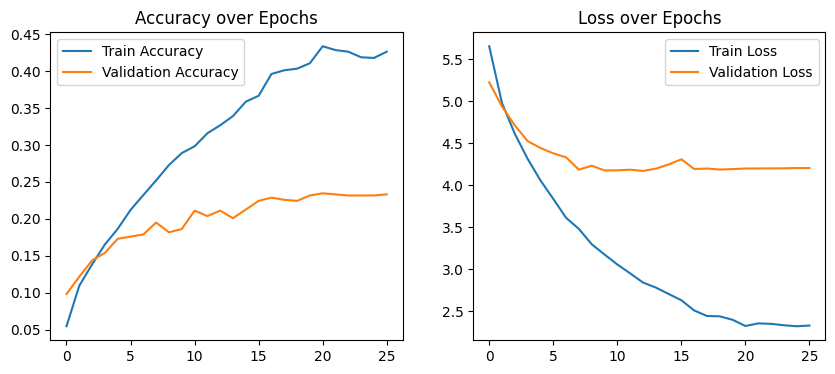

In [12]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.show()